In [1]:
# ###https://jef.works/STalign/notebooks/xenium-heimage-alignment.html

from STalign import STalign

In [2]:
import ants

In [3]:
# import dependencies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from skimage import io, color, filters, measure, morphology

# make plots bigger
plt.rcParams["figure.figsize"] = (12,10)

In [4]:
import scanpy as sc

In [5]:
adata = sc.read("../phaseF_newpipeline/sopa_seg/comb_h5ad/kidney_orig_seg_merged.h5ad")

/PHShome/qq06/.conda/envs/scimilarity/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
adata.shape

(421339, 4960)

In [7]:
adata.obsm['intensities']

,DAPI,ATP1A1/CD45/E-Cadherin,18S,AlphaSMA/Vimentin
aaaaaaaa-1,503.570064,567.283439,164.515924,408.840764
aaaaaaab-1,168.796646,776.364780,127.740042,1977.109015
aaaaaaac-1,1460.275246,1321.193923,165.408400,1022.024129
aaaaaaad-1,128.157235,828.527915,105.388150,58.601215
aaaaaaae-1,1835.097170,908.445283,171.493396,414.096226
...,...,...,...,...
aaaamfpb-1,2479.054750,777.439614,80.539452,1074.951691
aaaamfpc-1,271.655172,590.895690,141.815517,1573.577586
aaaamfpd-1,1892.365988,385.713740,118.407549,841.561917
aaaamfpe-1,2438.397146,2303.243757,133.599287,3544.799049


In [8]:
# #.obsm['intensities']
# sc.pl.scatter(adata, basis='spatial', feature='intensities')

(972, 1188, 3)

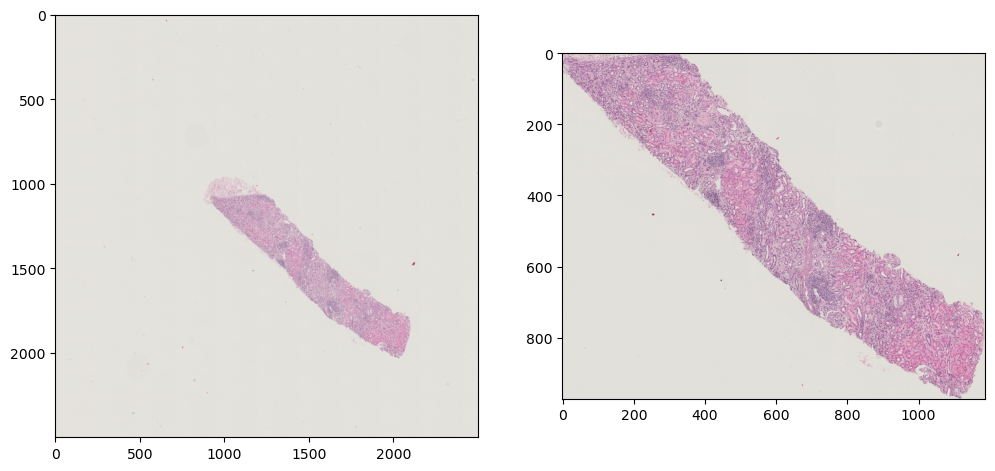

In [9]:
def cropped_HE(image_file):

    #V = plt.imread(image_file)

    image = io.imread(image_file)

    # If image has an alpha channel, drop it
    if image.shape[-1] == 4:
        image = image[:, :, :3] 

    # 1. Convert to grayscale
    gray = color.rgb2gray(image) if image.ndim == 3 else image

    # 2. Threshold to separate foreground from background
    thresh = filters.threshold_otsu(gray)
    binary = gray < thresh  # tissue often darker than background

    # Optional: remove small artifacts and fill holes
    binary = morphology.remove_small_objects(binary, min_size=500)
    binary = morphology.remove_small_holes(binary, area_threshold=500)

    # 3. Label connected components
    labeled = measure.label(binary)
    regions = measure.regionprops(labeled)

    # 4. Find the largest component
    largest_region = max(regions, key=lambda r: r.area)

    # 5. Get bounding box (min_row, min_col, max_row, max_col)
    minr, minc, maxr, maxc = largest_region.bbox

    pad_y = int((maxr - minr) * 0.001)
    pad_x = int((maxc - minc) * 0.001)

    h, w = image.shape[:2]

    minr = max(minr - pad_y, 0)
    maxr = min(maxr + pad_y, h)
    minc = max(minc - pad_x, 0)
    maxc = min(maxc + pad_x, w)

    # 6. Crop original image
    cropped = image[minr:maxr, minc:maxc]

    # plot
    fig,ax = plt.subplots(1, 2)
    #ax.imshow(V)
    ax[0].imshow(image)
    ax[1].imshow(cropped)
    Inorm = STalign.normalize(cropped)
    ax[1].imshow(Inorm)    
    return Inorm

#image_file = 'BD2025_15_3__2025-07-29_23.04.43.ndpi.png'
image_file = '../phaseZ_finalize_figs/BD2025_15_4__2025-07-29_23.06.53.ndpi.png'
cropped = cropped_HE(image_file)
cropped.shape

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


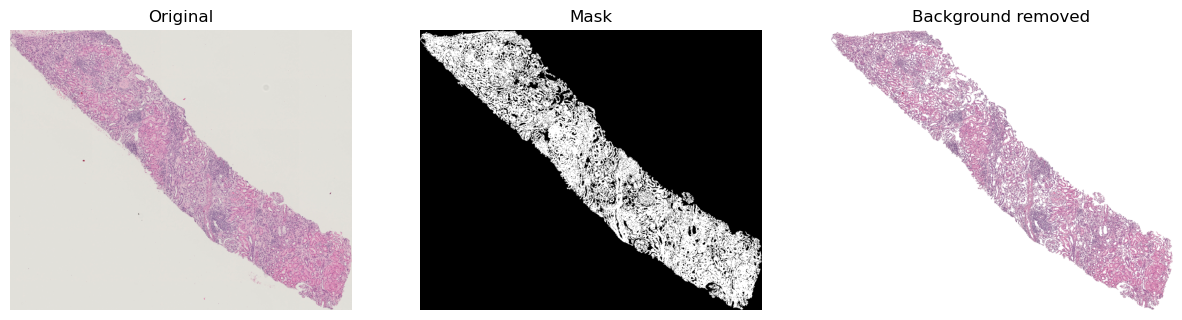

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology

# Convert to grayscale (brightness)
gray = color.rgb2gray(cropped)

# Threshold (Otsu finds the cutoff automatically)
thresh = filters.threshold_otsu(gray)

# Tissue mask: darker than threshold = tissue
mask = gray < thresh

# Optional: clean small specks
mask = morphology.remove_small_objects(mask, 50)

# Apply mask: set background to white
cropped_clean = cropped.copy()
cropped_clean[~mask] = [255, 255, 255]

# Show results
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(cropped)
axes[0].set_title("Original")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")
axes[2].imshow(cropped_clean)
axes[2].set_title("Background removed")
for ax in axes: ax.axis("off")
plt.show()


In [11]:
cropped = cropped_clean

In [12]:
def process_xenium_cells(fname):
    # Single cell data to be aligned
    df = pd.read_csv(fname)
    # get cell centroid coordinates
    xM = np.array(df['x_centroid'])
    yM = np.array(df['y_centroid'])

    # rasterize at 30um resolution (assuming positions are in um units) and plot
    XJ,YJ,M,fig = STalign.rasterize(xM, yM, dx=30)
    ax = fig.axes[0]
    ax.invert_yaxis()    
    # plot
    fig,ax = plt.subplots(1, 1)
    ax.scatter(xM,yM,s=1,alpha=0.2)
    return df, XJ, YJ, M, xM, yM

0 of 29368
10000 of 29368
20000 of 29368
29367 of 29368


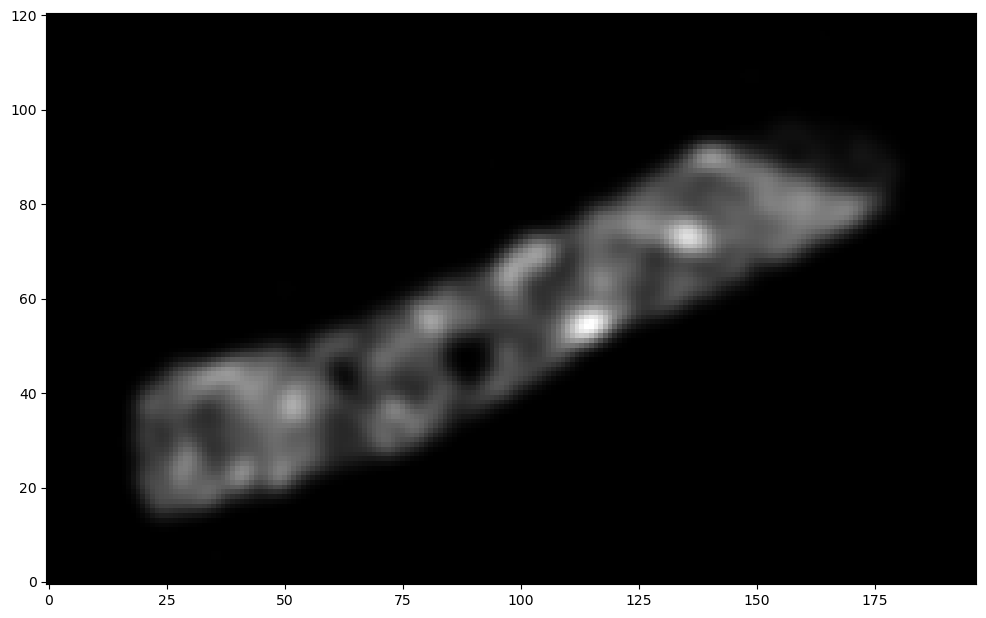

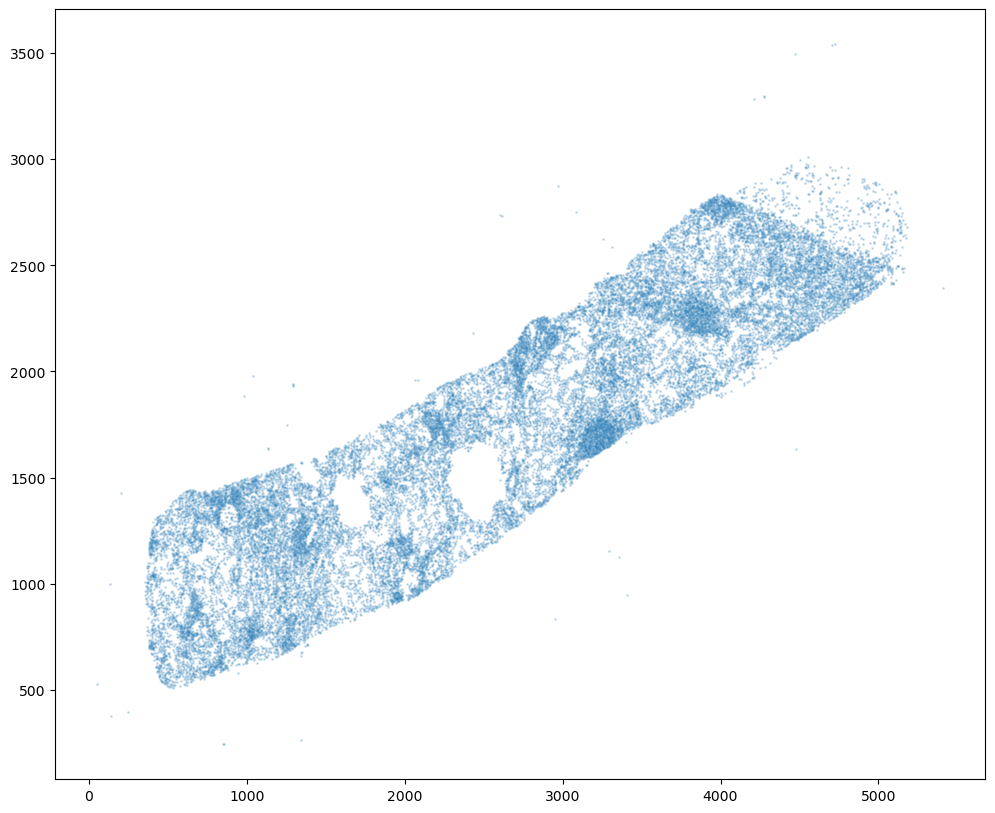

In [13]:
fname = '../data/kidney/20241025__200743__BWH_20241025_SHRUTI_RACHEL/output-XETG00392__0045655__BS21-N65682A2__20241025__201009/cells.csv.gz'
df, XJ, YJ, M, xM, yM = process_xenium_cells(fname)

In [14]:
M.shape

(1, 121, 197)

In [15]:
I = cropped.transpose(2,0,1)
print(I.shape)
YI = np.array(range(I.shape[1]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
XI = np.array(range(I.shape[2]))*1. # needs to be longs not doubles for STalign.transform later so multiply by 1.
extentI = STalign.extent_from_x((YI,XI))

print(M.shape)
J = np.vstack((M, M, M)) # make into 3xNxM
print(J.min())
print(J.max())

# normalize
J = STalign.normalize(J)
print(J.min())
print(J.max())

# double check size of things
print(I.shape)
print(M.shape)
print(J.shape)

(3, 972, 1188)
(1, 121, 197)
0.0
19.15863987985611
0.0
1.0
(3, 972, 1188)
(1, 121, 197)
(3, 121, 197)


In [16]:
J.shape, M.shape

((3, 121, 197), (1, 121, 197))

In [17]:
J.shape

(3, 121, 197)

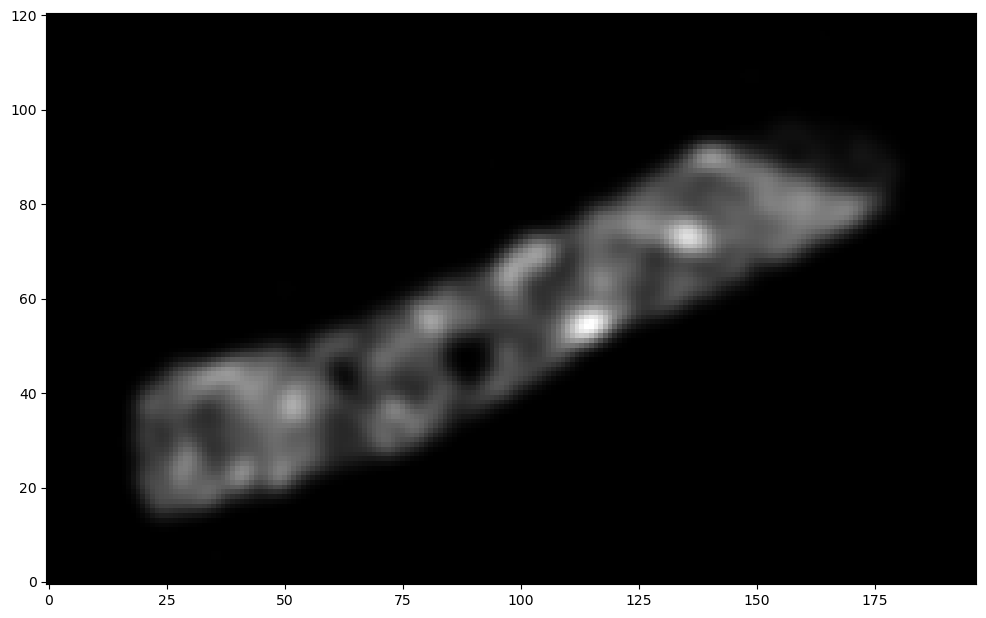

In [18]:
fig, ax = plt.subplots()
ax.imshow(J.transpose(1,2,0))
ax.invert_yaxis()

In [19]:
cropped.shape, J.shape

((972, 1188, 3), (3, 121, 197))

In [20]:
query = ants.from_numpy(cropped.mean(axis=-1))
target = ants.from_numpy(J.transpose(1,2,0)[:, :, 0])
trans = ants.registration(target, query, type_of_transform='Rigid')

In [21]:
mywarpedimage = ants.apply_transforms( fixed=target, moving=query,
                                       transformlist=trans['fwdtransforms'] )

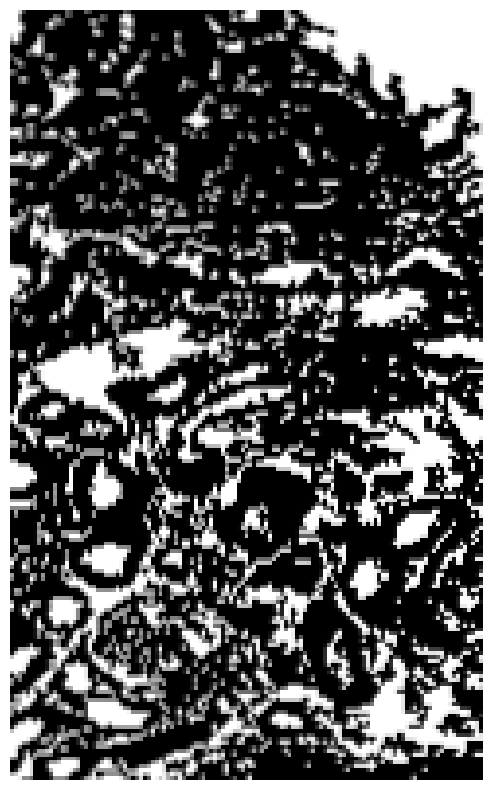

In [22]:
mywarpedimage.plot()

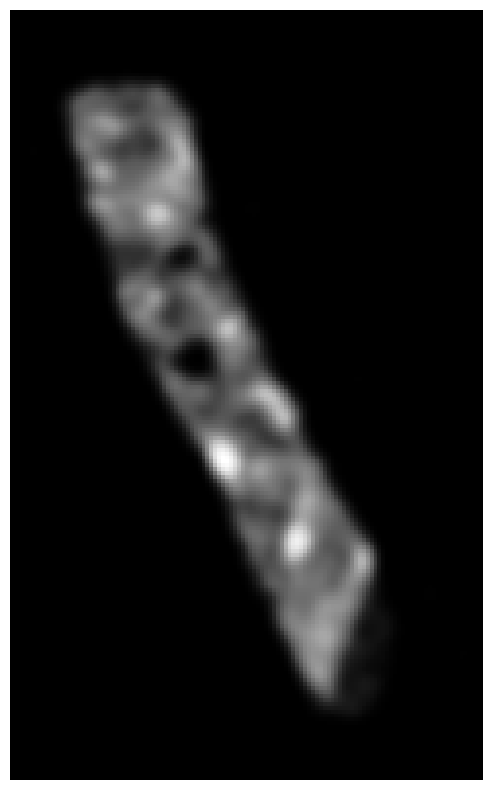

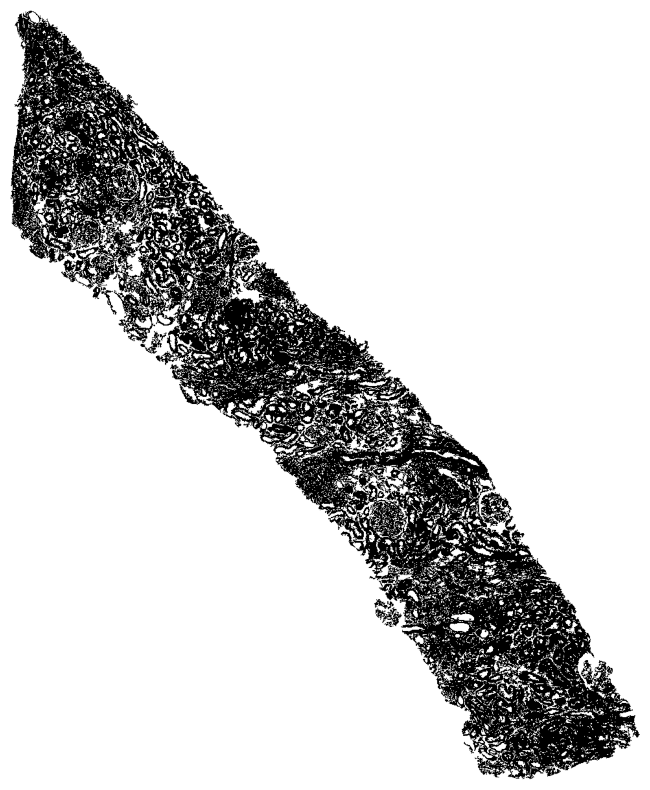

In [23]:
ants.plot(target)
ants.plot(query)

In [24]:
I.shape, J.shape

((3, 972, 1188), (3, 121, 197))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[[  23.25928124   31.70631212]
 [  38.25624243  346.30757578]
 [ 991.73524619 1113.31477157]
 [ 777.74923015 1208.67134053]]


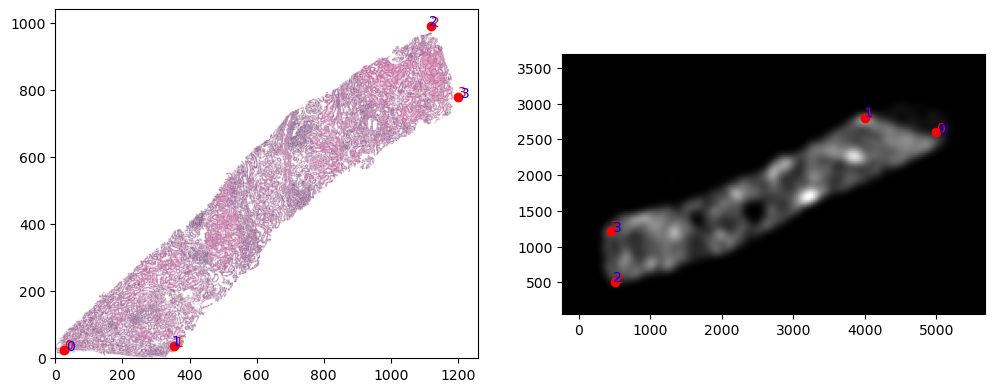

In [25]:
# manually make corresponding points
pointsI = np.array([[25, 25], [36, 355], [990, 1120], [780, 1200]])
pointsJ = np.array([[2600, 5000], [2800, 4000], [500, 500], [1225, 450]])

L,T = STalign.L_T_from_points(pointsI, pointsJ)

pointsJ_trans = L @ pointsI.T + T[:, None]
pointsI_trans = np.dot(np.linalg.inv(L), [pointsJ[:, 0] - T[0], pointsJ[:, 1] - T[1]]).T
print(pointsI_trans)

# plot
extentJ = STalign.extent_from_x((YJ,XJ))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red')
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red')
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[0].text(pointsI_trans[i,1],pointsI_trans[i,0],f'{i}', c='blue')
    
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')
    ax[1].text(pointsJ_trans[1, i],pointsJ_trans[0, i],f'{i}', c='blue')    

# invert only rasterized image
ax[1].invert_yaxis()
ax[0].invert_yaxis()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


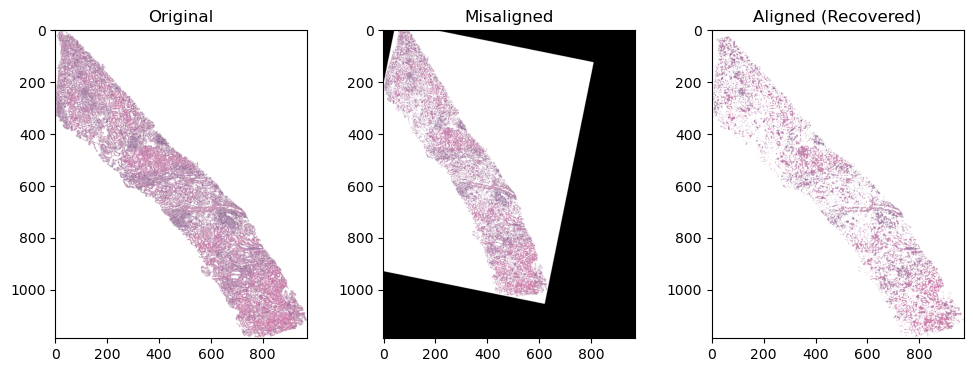

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import AffineTransform, warp, estimate_transform

# Load sample image
image = I.transpose(2, 1, 0)

# True transform (scale + rotate + translate)
tform_true = AffineTransform(scale=(0.8, 0.8), rotation=0.2, translation=(50, -30))

# Apply transform to simulate misaligned image
misaligned = warp(image, tform_true.inverse, output_shape=image.shape)

# Define corresponding points
src = np.array([[0, 0],
                [0, image.shape[0]],
                [image.shape[1], 0],
                [image.shape[1], image.shape[0]]])   # reference corners

dst = tform_true(src)  # transformed corners in misaligned space

# Recover transform (note the order: misaligned→reference)
tform_est = estimate_transform("affine", dst, src)

# Warp misaligned back
aligned = warp(misaligned, tform_est.inverse, output_shape=image.shape,
               mode='constant',   # treat out-of-bounds coordinates as constant
               cval=1.0)

# Show results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(misaligned, cmap='gray')
axes[1].set_title('Misaligned')

axes[2].imshow(aligned, cmap='gray')
axes[2].set_title('Aligned (Recovered)')
plt.show()


In [27]:
# M2 = np.eye(3)
# M2[:2, :2] = L
# M2[:2, 2] = T   # translation
# M2

In [28]:
# import numpy as np
# import matplotlib.pyplot as plt
# from skimage import data
# from skimage.transform import AffineTransform, warp, estimate_transform

# # Load sample image
# image = I.transpose(2, 1, 0)

# # True transform (scale + rotate + translate)
# tform_true = AffineTransform(scale=(0.8, 0.8), rotation=0.2, translation=(50, -30))

# # Apply transform to simulate misaligned image
# misaligned = warp(image, tform_true.inverse, output_shape=image.shape)

# # Define corresponding points
# src = np.array([[0, 0],
#                 [0, image.shape[0]],
#                 [image.shape[1], 0],
#                 [image.shape[1], image.shape[0]]])   # reference corners

# dst = tform_true(src)  # transformed corners in misaligned space

# # Recover transform (note the order: misaligned→reference)
# tform_est = estimate_transform("affine", pointsI, pointsJ)

# # Warp misaligned back
# aligned = warp(I.transpose(1, 2, 0), tform_est.inverse, output_shape=J.shape[1:],
#                mode='constant',   # treat out-of-bounds coordinates as constant
#                cval=1.0)

# # Show results
# fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# axes[0].imshow(image, cmap='gray', extent=extentI)
# axes[0].set_title('Original')

# axes[1].imshow(misaligned, cmap='gray')
# axes[1].set_title('Misaligned')

# axes[2].imshow(aligned, cmap='gray')
# axes[2].set_title('Aligned (Recovered)')
# plt.show()


In [29]:
J.shape, I.shape

((3, 121, 197), (3, 972, 1188))

[[  23.25928124   31.70631212]
 [  38.25624243  346.30757578]
 [ 991.73524619 1113.31477157]
 [ 777.74923015 1208.67134053]]
<AffineTransform(matrix=
    [[-3.12341577e+00, -1.15819816e+00,  5.12597085e+03],
     [ 7.80650801e-01, -3.04019781e+00,  2.64596126e+03],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])>
<AffineTransform(matrix=
    [[-2.92328115e-01,  1.11365742e-01,  1.20379596e+03],
     [-7.50629372e-02, -3.00329880e-01,  1.17943165e+03],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])>
<AffineTransform(matrix=
    [[-3.12485082e+00, -1.15674790e+00,  5.12627565e+03],
     [ 7.83821799e-01, -3.04397522e+00,  2.64554994e+03],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])>
<AffineTransform(matrix=
    [[-2.92165918e-01,  1.11026631e-01,  1.20399653e+03],
     [-7.52325491e-02, -2.99928495e-01,  1.17913860e+03],
     [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])>


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


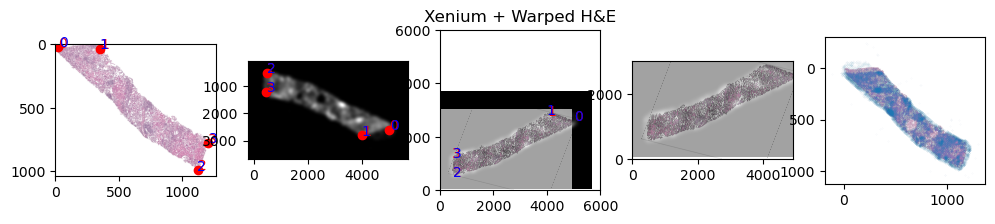

In [30]:
import numpy as np
from skimage.transform import warp

pointsI = np.array([[25, 25], [36, 355], [990, 1120], [780, 1200]])
pointsJ = np.array([[2600, 5000], [2800, 4000], [500, 500], [1225, 450]])

L,T = STalign.L_T_from_points(pointsI, pointsJ)

pointsI_trans = np.dot(np.linalg.inv(L), [pointsJ[:, 0] - T[0], pointsJ[:, 1] - T[1]]).T
pointsJ_trans = L @ pointsI.T + T[:, None]

print(pointsI_trans)

# plot
extentJ = STalign.extent_from_x((YJ,XJ))

# Define inverse map in row/col (y,x) coordinates
L_inv = np.linalg.inv(L)

# note points are as y,x
affine = np.dot(np.linalg.inv(L), [yM - T[0], xM - T[1]])
xMaffine = affine[0,:]
yMaffine = affine[1,:]

#pointsJ_trans = L @ pointsI.T + T[:, None]
#affine = np.dot(np.linalg.inv(L), [yM - T[0], xM - T[1]])
#pointsI_trans = np.dot(np.linalg.inv(L), [pointsJ[:, 0] - T[0], pointsJ[:, 1] - T[1]]).T
#print(pointsI_trans)

def inverse_map(coords):
    """
    coords: (N, 2) array of (row, col) = (y, x) in output space
    returns: (N, 2) array of (row, col) in input space
    """
    y, x = coords[:, 0], coords[:, 1]  # row, col
    xy = np.dot(L_inv, np.vstack([y - T[0], x - T[1]]))
    y_in, x_in = xy[0, :], xy[1, :]
    return np.vstack([x_in, y_in]).T

L,T = STalign.L_T_from_points(pointsI[:, ::-1], pointsJ[:, ::-1])
M1 = np.vstack([np.hstack([L, T[:, None]]), [0,0,1]])
M2 = np.eye(3)
M2[:2, :2] = L
M2[:2, 2] = T   # translation
assert (M1-M2).sum()==0
tform = AffineTransform(matrix=M2)
print(tform)
print(tform.inverse)

tform = estimate_transform("affine", pointsI[:, ::-1], pointsJ[:, ::-1])
print(tform)
print(tform.inverse)

# Warp H&E directly
I_rgb = I.transpose(1, 2, 0)   # (H, W, C)
h, w = I_rgb.shape[:2]
I_warped = warp(
    I_rgb,
   # inverse_map=inverse_map,
    inverse_map=tform.inverse,
    output_shape=(J.shape[1]*25, J.shape[2]*25),  # big enough canvas    
    order=3,
    mode="constant",
    cval=1.0
)

fig,ax = plt.subplots(1, 5)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI)
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ)

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red')
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red')
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[0].text(pointsI_trans[i,1],pointsI_trans[i,0],f'{i}', c='blue')
    
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')
    ax[1].text(pointsJ_trans[1, i],pointsJ_trans[0, i],f'{i}', c='blue')    

    ax[2].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')
    ax[2].text(pointsJ_trans[1, i],pointsJ_trans[0, i],f'{i}', c='blue')        

ax[2].imshow(J.transpose(1, 2, 0).squeeze(), extent=extentJ)
ax[2].imshow(I_warped, alpha=0.64)
ax[2].set_ylim(0, 6000)
ax[2].set_xlim(0, 6000)
ax[2].set_title("Xenium + Warped H&E")

ax[3].imshow(J.transpose(1, 2, 0).squeeze(), extent=extentJ)
ax[3].imshow(I_warped, alpha=0.64)
ax[3].invert_yaxis()

# plot
ax[4].imshow(cropped) 
ax[4].scatter(yMaffine,xMaffine,s=0.05,alpha=0.05)

# for a in ax: 
#     a.invert_yaxis()
plt.show()